# Install & Import Libraries

In [35]:
!pip install -q gensim 
!pip install -q nltk
!pip install -q spacy
!python -m spacy download en_core_web_sm --quiet
!pip install -q transformers
!pip install -q torch
!pip install -q hf_xet
!pip install -q numpy
%pip uninstall -y gensim numpy > /dev/null 2>&1
%pip install -q numpy==1.26.4
%pip install -q gensim==4.3.1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *
from nltk.tokenize import TreebankWordTokenizer
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import hf_xet
import spacy

In [2]:
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim import corpora
from gensim.models.ldaseqmodel import LdaSeqModel

# Load Data

In [3]:
df_transcripts = pd.read_csv('debate_transcripts_cleaned.csv', encoding='utf-8')

In [4]:
df_transcripts = df_transcripts[df_transcripts["is_candidate"] == True].copy()

# Add First Names of Candidates

In [5]:
candidate_first_names = {
    "Kennedy": "John",
    "Humphrey": "Hubert",
    "McGovern": "George",
    "Carter": "Jimmy",
    "Mondale": "Walter",
    "Dukakis": "Michael",
    "Clinton (Bill)": "Bill",
    "Clinton Bill": "Bill",
    "Gore": "Al",
    "Kerry": "John",
    "Obama": "Barack",
    "Clinton Hillary": "Hillary",
    "Biden": "Joe",

    "Nixon": "Richard",
    "Goldwater": "Barry",
    "Ford": "Gerald",
    "Reagan": "Ronald",
    "Bush Sr": "George",  
    "Bush Jr": "George",
    "Dole": "Bob",
    "Mccain": "John",
    "Romney": "Mitt",
    "Trump": "Donald",
    "DeSantis": "Ron",
    "Kemp": "Jack",

    "Wallace": "George",
    "Perot": "Ross",
    "Kennedy Jr.": "Robert",
    "West": "Cornel",
    "Ramaswamy": "Vivek",
    "Anderson": "John",

    "Johnson": "Lyndon",
    "Agnew": "Spiro",
    "Rockefeller": "Nelson",
    "Muskie": "Edmund",
    "Miller": "William",
    "Ferraro": "Geraldine",
    "Quayle": "Dan",
    "Lieberman": "Joe",
    "Edwards": "John",
    "Palin": "Sarah",
    "Ryan": "Paul",
    "Pence": "Mike",
    "Harris": "Kamala",
    "Cheney": "Dick",
    "Bentsen": "Lloyd",
    "Kaine": "Tim",
    "Stockdale": "James",
    "Walz": "Tim",
    "Vance": "J.D."
}

df_transcripts["first_name"] = df_transcripts["actor"].map(candidate_first_names)

In [7]:
df_transcripts.head()

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,first_name
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,John
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,Richard
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,John
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,I have no comment.,True,Republican,False,False,False,Richard
10,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,It would be rather difficult to cover them in ...,True,Republican,False,False,False,Richard


# Preprocess Data

In [6]:
# Download only necessary resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Initialize tools
tokenizer = TreebankWordTokenizer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing text
def text_preprocess(text):
    if pd.isnull(text):
        return ""
    tokens = tokenizer.tokenize(text)
    filtered_tokens = [word.lower() for word in tokens if word.isalpha() and word.lower() not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lemmatized_tokens)

# Apply to your dataframe
df_transcripts["cleaned_text"] = df_transcripts["dialogue"].apply(text_preprocess)

# Preview
df_transcripts[["dialogue", "cleaned_text"]].head(10)

[nltk_data] Downloading package stopwords to /home/ucloud/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/ucloud/nltk_data...
[nltk_data] Error loading tokenizers: Package 'tokenizers' not found
[nltk_data]     in index
[nltk_data] Downloading package punkt to /home/ucloud/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,dialogue,cleaned_text
0,"Mr. Smith, Mr. Nixon. In the election of 1860,...",smith election abraham lincoln said question w...
2,"Mr. Smith, Senator Kennedy. The things that Se...",smith senator thing senator kennedy said many ...
5,"Well, the Vice President and I came to the Con...",well vice president came congress together ser...
7,I have no comment.,comment
10,It would be rather difficult to cover them in ...,would rather difficult cover eight two half wo...
11,"Well, I would say in the latter that the and ...",well would say latter thats found uh somewhat ...
14,Thats correct.,thats correct
16,"Well, because I think that if the federal gove...",well think federal government moved program wi...
20,"Well, I would suggest, Mr. Vanocur, that uh i...",well would suggest vanocur uh know president p...
22,"Well, Ill just say that the question is of exp...",well ill say question experience question also...


# Remove "NON-NOUNS and NON-ADJECTIVES" using POS-Tagging

Non-Nouns and Non-Adjectives were deemed not necessary to identify topics across the political landscape

In [7]:
# Lade spaCy Modell
nlp = spacy.load("en_core_web_sm")

# Funktion zum Filtern von NOUN, ADJ, PROPN
def keep_nouns_adjectives_spacy(text):
    if pd.isnull(text):
        return ""
    doc = nlp(text)
    return " ".join([token.text.lower() for token in doc if token.pos_ in {"NOUN", "ADJ", "PROPN"}])

# Anwenden auf DataFrame
df_transcripts["cleaned_text"] = df_transcripts["cleaned_text"].apply(keep_nouns_adjectives_spacy)

# Identify and Remove "Domain-specific Stopwords"

Remove Candidate Names

In [8]:
# Step 1: Collect all lowercase actor names
actor_words_to_remove = set(df_transcripts['actor'].dropna().str.lower().str.strip())

# Step 2: Collect all lowercase first names from your mapping
first_names_to_remove = set(name.lower() for name in candidate_first_names.values())

# Step 3: Combine into one set of stopwords
names_to_remove = actor_words_to_remove.union(first_names_to_remove)
names_to_remove.update(["clinton", "bush"])

# Step 4: Define a clean-up function
def remove_names(text):
    if pd.isnull(text):
        return text
    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word.lower() not in names_to_remove]
    return " ".join(cleaned_tokens)

# Step 5: Apply to cleaned_text column
df_transcripts["cleaned_text"] = df_transcripts["cleaned_text"].apply(remove_names)

Identify Frequent Words without Topic Contribution

In [12]:
from collections import Counter
import pandas as pd

# Combine all cleaned text into one long string
all_text = " ".join(df_transcripts["cleaned_text"].dropna())

# Split into words
words = all_text.split()

# Count frequency
word_counts = Counter(words)

# Get the 200 most common words
top_300_df = word_counts.most_common(300)

# Ensure all rows are shown
pd.set_option('display.max_rows', 300)

# Display interactively
top_300_df

[('people', 3125),
 ('president', 2266),
 ('tax', 1642),
 ('year', 1610),
 ('american', 1477),
 ('country', 1388),
 ('state', 1335),
 ('thing', 1171),
 ('time', 1103),
 ('job', 948),
 ('way', 928),
 ('united', 899),
 ('america', 897),
 ('senator', 828),
 ('government', 779),
 ('world', 773),
 ('right', 700),
 ('good', 697),
 ('new', 693),
 ('plan', 676),
 ('sure', 658),
 ('lot', 649),
 ('governor', 646),
 ('fact', 642),
 ('last', 637),
 ('health', 619),
 ('money', 619),
 ('care', 598),
 ('administration', 570),
 ('family', 569),
 ('program', 556),
 ('number', 530),
 ('great', 525),
 ('work', 522),
 ('security', 522),
 ('first', 519),
 ('many', 511),
 ('war', 502),
 ('percent', 498),
 ('problem', 487),
 ('important', 486),
 ('question', 480),
 ('kind', 474),
 ('business', 471),
 ('able', 470),
 ('nation', 466),
 ('economy', 461),
 ('child', 454),
 ('know', 447),
 ('talk', 444),
 ('cut', 436),
 ('policy', 430),
 ('congress', 426),
 ('issue', 424),
 ('day', 412),
 ('federal', 407),
 ('nuc

In [13]:
# Collect top 300 most frequent words
all_text = " ".join(df_transcripts["cleaned_text"].dropna())
top_words = [word for word, _ in Counter(all_text.split()).most_common(300)]

# Define exception list
exception_words = {
    "tax", "job", "right", "health", "money", "care", "family", "program",
    "work", "security", "war", "business", "economy", "child", "cut", "nuclear",
    "school", "military", "woman", "budget", "social", "energy", "economic", "life",
    "law", "dollar", "education", "deal", "rate", "ill", "middle", "support",
    "weapon", "system", "cost", "drug", "young", "decision", "company", "iraq",
    "troop", "foreign", "medicare", "help", "force", "course", "oil", "defense",
    "opportunity", "soviet", "deficit", "kid", "china", "iran", "control", "increase",
    "insurance", "income", "pay", "trade", "house", "case", "power", "credit",
    "community", "word", "peace", "union", "ally", "russia", "court", "growth",
    "debt", "freedom", "effort", "use", "border", "order", "chance", "class",
    "terrorist", "college", "teacher", "action", "threat", "parent", "strength",
    "crime", "afghanistan", "arm", "call", "gun", "inflation", "member", "clean",
    "unemployment", "top", "israel", "price", "benefit", "taxpayer", "market",
    "worker", "justice", "saddam", "housing", "investment", "safe", "fund", "east",
    "russian", "sanction", "abortion", "police", "love", "regard", "fight", "lower",
    "crisis", "human", "attack", "industry", "welfare"
}

# Compute frequent words to remove (excluding exceptions)
top_words_set = set(top_words)
words_to_remove = top_words_set - exception_words

# Clean function with filtering
def clean_with_exceptions(text):
    if pd.isnull(text):
        return ""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in words_to_remove]
    return " ".join(filtered_tokens)

# Apply to DataFrame
df_transcripts["cleaned_text"] = df_transcripts["cleaned_text"].apply(clean_with_exceptions)

# Preview result
df_transcripts[["actor", "dialogue", "cleaned_text"]].head(10)

,actor,dialogue,cleaned_text
0,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",smith abraham lincoln direction freedom direct...
2,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",smith discus internal affair tremendous intern...
5,Kennedy,"Well, the Vice President and I came to the Con...",labor period program advocate century woodrow ...
7,Nixon,I have no comment.,comment
10,Nixon,It would be rather difficult to cover them in ...,difficult foreign trip recommendation trip inc...
11,Kennedy,"Well, I would say in the latter that the and ...",latter unsatisfactory figure previous speech t...
14,Kennedy,Thats correct.,correct
16,Kennedy,"Well, because I think that if the federal gove...",program support economic farmer plant spring h...
20,Nixon,"Well, I would suggest, Mr. Vanocur, that uh i...",facetious improper instance member official fa...
22,Kennedy,"Well, Ill just say that the question is of exp...",ill goal ability abraham lincoln presidency se...


In [14]:
# Drop rows where cleaned_text is empty or just whitespace
df_transcripts = df_transcripts[df_transcripts["cleaned_text"].str.strip() != ""]

# Preview the result
df_transcripts.head(10)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,first_name,cleaned_text
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,John,smith abraham lincoln direction freedom direct...
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,Richard,smith discus internal affair tremendous intern...
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,John,labor period program advocate century woodrow ...
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,I have no comment.,True,Republican,False,False,False,Richard,comment
10,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,It would be rather difficult to cover them in ...,True,Republican,False,False,False,Richard,difficult foreign trip recommendation trip inc...
11,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Well, I would say in the latter that the and ...",True,Democratic,True,False,False,John,latter unsatisfactory figure previous speech t...
14,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,Thats correct.,True,Democratic,True,False,False,John,correct
16,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Well, because I think that if the federal gove...",True,Democratic,True,False,False,John,program support economic farmer plant spring h...
20,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,"Well, I would suggest, Mr. Vanocur, that uh i...",True,Republican,False,False,False,Richard,facetious improper instance member official fa...
22,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Well, Ill just say that the question is of exp...",True,Democratic,True,False,False,John,ill goal ability abraham lincoln presidency se...


# Dynamic Topic Modeling

## Investigate the optimal number of topics for a simple LDA using UMass (inspired by Noble et al. (2021))

Topics: 3, UMass Coherence: -2.4366
Topics: 4, UMass Coherence: -3.2063
Topics: 5, UMass Coherence: -2.8431
Topics: 6, UMass Coherence: -3.3242
Topics: 7, UMass Coherence: -3.5359
Topics: 8, UMass Coherence: -4.9592
Topics: 9, UMass Coherence: -4.0082
Topics: 10, UMass Coherence: -4.2336
Topics: 11, UMass Coherence: -4.7749
Topics: 12, UMass Coherence: -5.5743
Topics: 13, UMass Coherence: -4.7883
Topics: 14, UMass Coherence: -5.5308
Topics: 15, UMass Coherence: -5.4036
Topics: 16, UMass Coherence: -5.4739
Topics: 17, UMass Coherence: -6.2434
Topics: 18, UMass Coherence: -5.8893
Topics: 19, UMass Coherence: -5.8816
Topics: 20, UMass Coherence: -6.4225


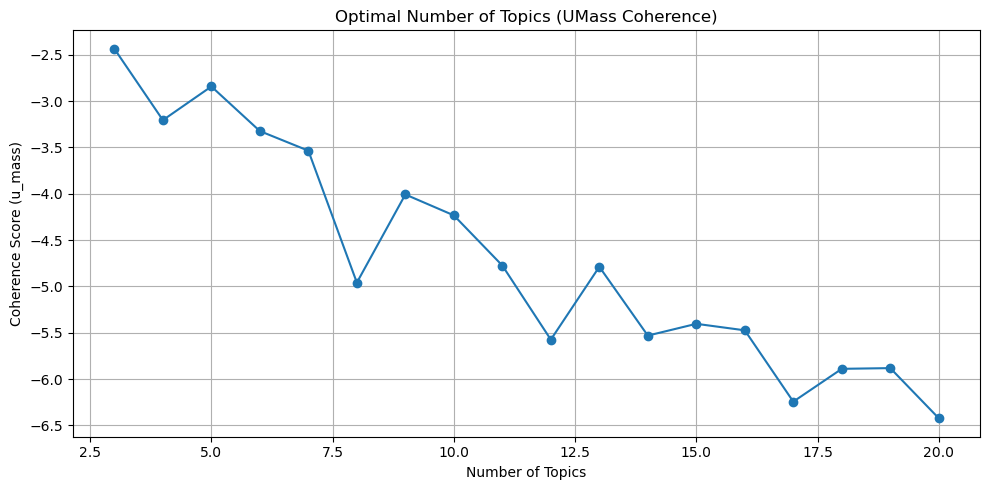

In [40]:
# Use preprocessed tokenized texts and dictionary
texts = all_docs_5_topics  # tokenized speeches (per speech, not per year)
dictionary = dictionary_5_topics
corpus = corpus_5_topics

# Range of topic numbers to evaluate
topic_range = range(3, 21)
coherence_scores = []

# Train independent LDA models and compute UMass coherence for each topic count
for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=35,
        random_state=42  # keeps the results reproducible, but each model is independent
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)
    print(f"Topics: {num_topics}, UMass Coherence: {coherence:.4f}")

# Plot coherence scores vs number of topics
plt.figure(figsize=(10, 5))
plt.plot(topic_range, coherence_scores, marker='o')
plt.title("Optimal Number of Topics (UMass Coherence)")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (u_mass)")
plt.grid(True)
plt.tight_layout()
plt.show()

### num_topics = 3

In [39]:
# Tokenize cleaned text into words
df_transcripts["tokens"] = df_transcripts["cleaned_text"].apply(lambda x: x.split())

# Group tokenized speeches by year and sort chronologically
grouped = df_transcripts.groupby("year")["tokens"].apply(list).sort_index()

# Flatten speeches into one document per speech; count speeches per year
all_docs_3_topics = [doc for year_docs in grouped for doc in year_docs]
timeslices_3_topics = [len(year_docs) for year_docs in grouped]

# Create a dictionary of words and a bag-of-words corpus
dictionary_3_topics = corpora.Dictionary(all_docs_3_topics)
corpus_3_topics = [dictionary_3_topics.doc2bow(text) for text in all_docs_3_topics]

# Train the Dynamic Topic Model with 3 topics
ldaseq_3_topics = LdaSeqModel(
    corpus=corpus_3_topics,
    time_slice=timeslices_3_topics,
    id2word=dictionary_3_topics,
    num_topics=3,
    initialize='gensim',
    random_state=42
)

/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:298: RuntimeWarning: divide by zero encountered in scalar divide
  convergence = np.fabs((bound - old_bound) / old_bound)


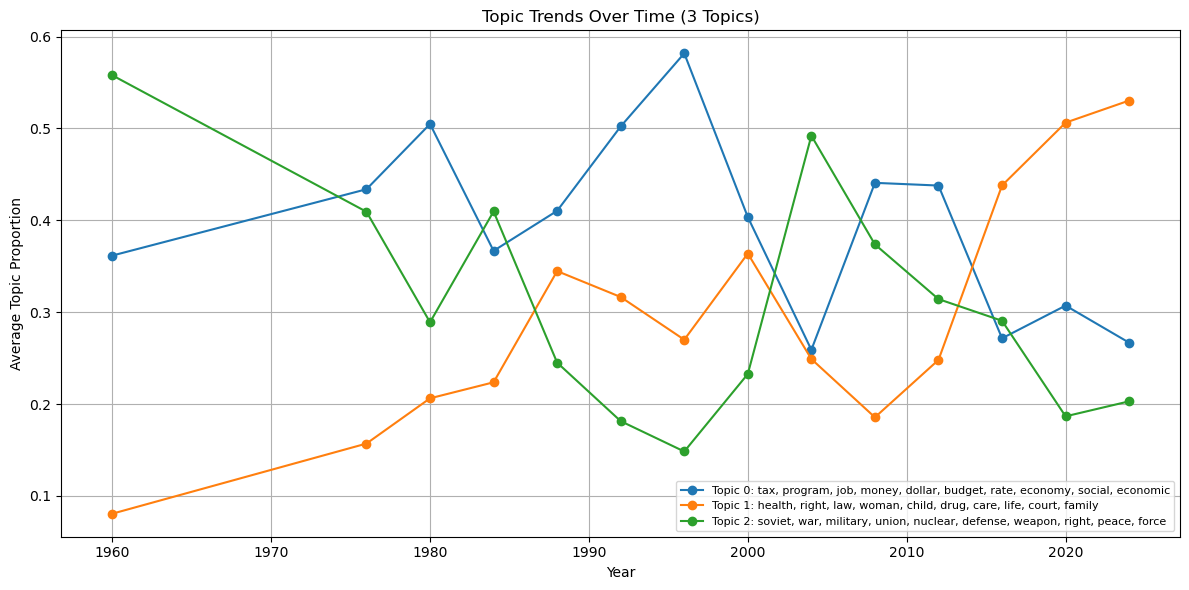

In [36]:
doc_topic_dists_3 = [ldaseq_3_topics.doc_topics(i) for i in range(len(all_docs_3_topics))]
topic_df_3 = pd.DataFrame(doc_topic_dists_3, columns=[f"Topic {i}" for i in range(ldaseq_3_topics.num_topics)])

years_per_doc_3 = []
for year, docs in grouped.items():
    years_per_doc_3.extend([year] * len(docs))
topic_df_3["year"] = years_per_doc_3

topic_trends_3 = topic_df_3.groupby("year").mean()

topic_labels_3 = []
for topic_id in range(ldaseq_3_topics.num_topics):
    top_terms = ldaseq_3_topics.print_topic(topic=topic_id, time=0, top_terms=10)
    label = f"Topic {topic_id}: " + ", ".join([term for term, _ in top_terms])
    topic_labels_3.append(label)

plt.figure(figsize=(12, 6))
for i, col in enumerate(topic_trends_3.columns):
    plt.plot(topic_trends_3.index, topic_trends_3[col], marker='o', label=topic_labels_3[i])

plt.title("Topic Trends Over Time (3 Topics)")
plt.xlabel("Year")
plt.ylabel("Average Topic Proportion")
plt.legend(loc='best', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### num_topics = 5

In [ ]:
# Tokenize cleaned text into words
df_transcripts["tokens"] = df_transcripts["cleaned_text"].apply(lambda x: x.split())

# Group tokenized speeches by year and sort chronologically
grouped = df_transcripts.groupby("year")["tokens"].apply(list).sort_index()

# Flatten speeches into one document per speech; count speeches per year
all_docs_5_topics = [doc for year_docs in grouped for doc in year_docs]
timeslices_5_topics = [len(year_docs) for year_docs in grouped]

# Create a dictionary of words and a bag-of-words corpus
dictionary_5_topics = corpora.Dictionary(all_docs_5_topics)
corpus_5_topics = [dictionary_5_topics.doc2bow(text) for text in all_docs_5_topics]

# Train the Dynamic Topic Model with 5 topics
ldaseq_5_topics = LdaSeqModel(
    corpus=corpus_5_topics,
    time_slice=timeslices_5_topics,
    id2word=dictionary_5_topics,
    num_topics=5,
    initialize='gensim',
    random_state=42
)

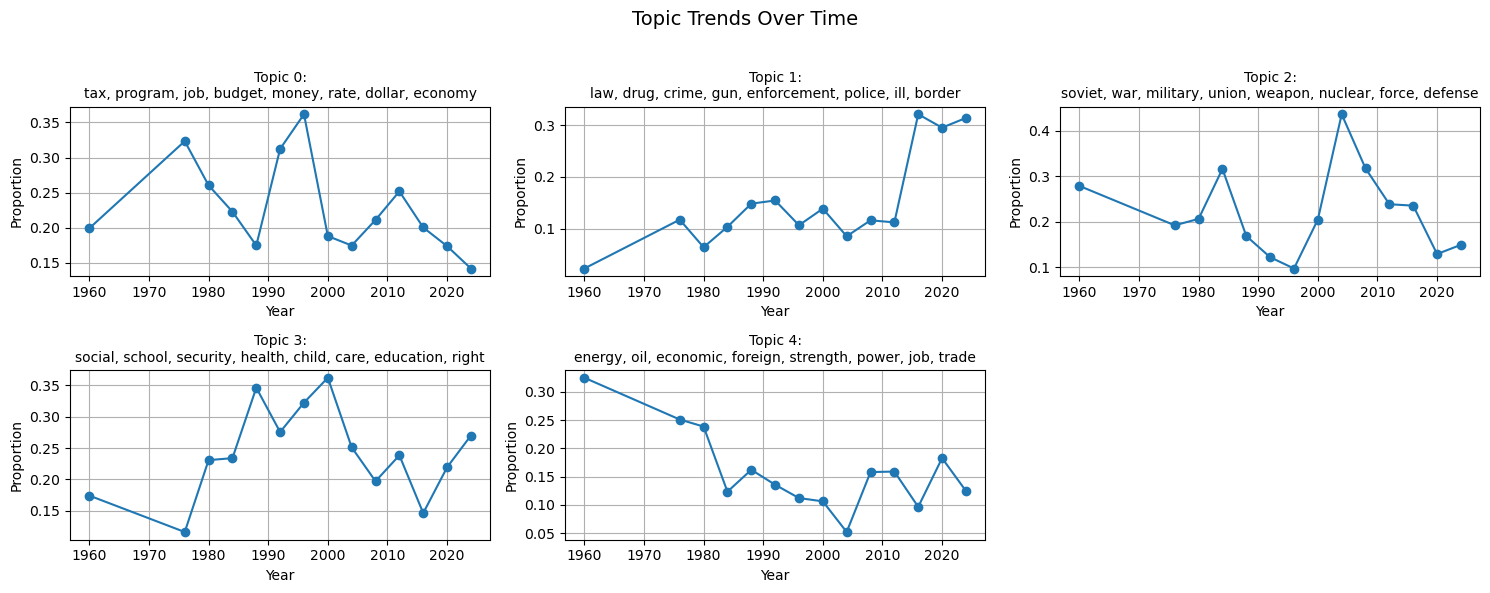

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get topic proportions per document
doc_topic_dists_5 = [ldaseq_5_topics.doc_topics(i) for i in range(len(all_docs_5_topics))]
topic_df_5 = pd.DataFrame(doc_topic_dists_5, columns=[f"Topic {i}" for i in range(ldaseq_5_topics.num_topics)])

# Step 2: Match each document to its year
years_per_doc_5 = []
for year, docs in grouped.items():
    years_per_doc_5.extend([year] * len(docs))
topic_df_5["year"] = years_per_doc_5

# Step 3: Average topic proportions per year
topic_trends_5 = topic_df_5.groupby("year").mean()

# Step 4: Get top 8 terms per topic (from the first time slice)
topic_labels_5 = []
for topic_id in range(ldaseq_5_topics.num_topics):
    top_terms = ldaseq_5_topics.print_topic(topic=topic_id, time=0, top_terms=8)
    label = f"Topic {topic_id}:\n" + ", ".join([term for term, _ in top_terms])
    topic_labels_5.append(label)

# Step 5: Plot in a grid (adjust layout based on number of topics)
n_topics = ldaseq_5_topics.num_topics
n_rows = (n_topics + 2) // 3  # Adjust layout: 3 columns
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i in range(n_topics):
    ax = axes[i]
    ax.plot(topic_trends_5.index, topic_trends_5[f"Topic {i}"], marker='o')
    ax.set_title(topic_labels_5[i], fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion")
    ax.grid(True)

# Hide any unused subplots
for j in range(n_topics, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Topic Trends Over Time", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

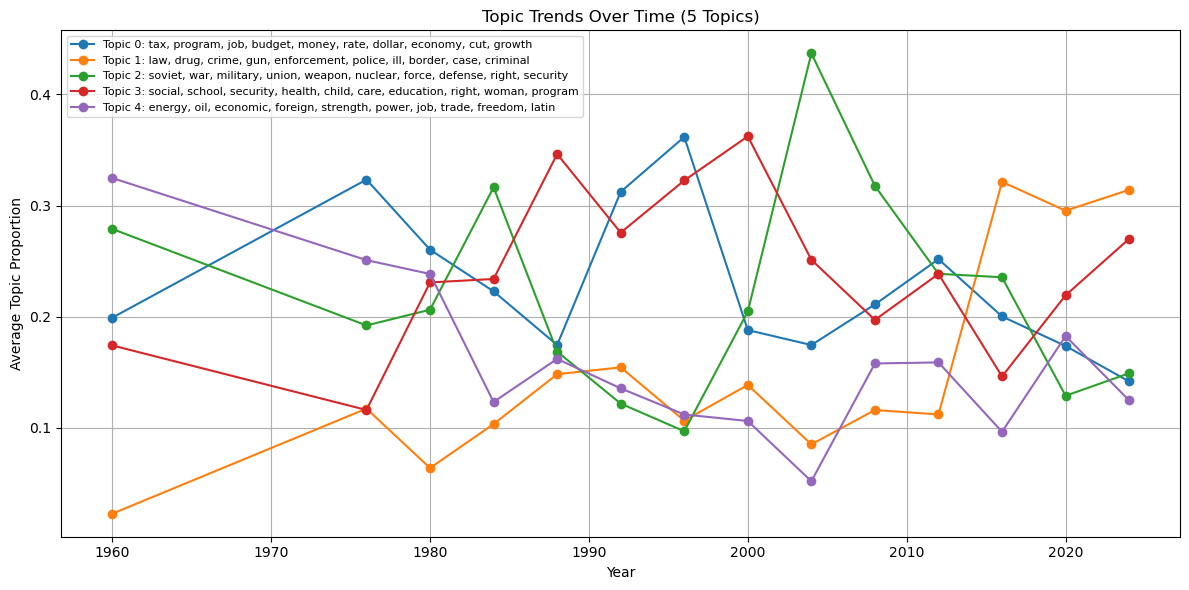

In [38]:
# Get topic proportions per document
doc_topic_dists_5 = [ldaseq_5_topics.doc_topics(i) for i in range(len(all_docs_5_topics))]
topic_df_5 = pd.DataFrame(doc_topic_dists_5, columns=[f"Topic {i}" for i in range(ldaseq_5_topics.num_topics)])

# Match each document to its corresponding year
years_per_doc_5 = []
for year, docs in grouped.items():
    years_per_doc_5.extend([year] * len(docs))
topic_df_5["year"] = years_per_doc_5

# Average topic proportions per year
topic_trends_5 = topic_df_5.groupby("year").mean()

# Get top 10 terms per topic (from the first time slice)
topic_labels_5 = []
for topic_id in range(ldaseq_5_topics.num_topics):
    top_terms = ldaseq_5_topics.print_topic(topic=topic_id, time=0, top_terms=10)
    label = f"Topic {topic_id}: " + ", ".join([term for term, _ in top_terms])
    topic_labels_5.append(label)

# Plot all topic trends on one graph
plt.figure(figsize=(12, 6))
for i, col in enumerate(topic_trends_5.columns):
    plt.plot(topic_trends_5.index, topic_trends_5[col], marker='o', label=topic_labels_5[i])

plt.title("Topic Trends Over Time (5 Topics)")
plt.xlabel("Year")
plt.ylabel("Average Topic Proportion")
plt.legend(loc='best', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

## Create Topic Word Lists

In [24]:
# Extract top 30 terms per topic from the first time slice
topic_keywords = {}

for topic_id in range(ldaseq.num_topics):
    top_terms = ldaseq.print_topic(topic=topic_id, time=0, top_terms=30)
    words_only = [term for term, _ in top_terms]
    topic_keywords[f"Topic {topic_id}"] = words_only

# Convert to DataFrame
topic_keywords_df = pd.DataFrame.from_dict(topic_keywords, orient='index').transpose()

# Show the full DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Display
print(topic_keywords_df)

      Topic 0       Topic 1        Topic 2     Topic 3       Topic 4  \
0      school          iran         energy      soviet           tax   
1   education       nuclear            oil         war       program   
2       money        israel            new       union           job   
3       house       foreign          clean       first           cut   
4     teacher         right            use    military          rate   
5      budget        weapon           coal      nation       economy   
6       child        saddam           land     defense      increase   
7      public          ally          right       force      economic   
8      dollar         north    opportunity    position         money   
9     program           war           work    strength        dollar   
10      first        middle            job       peace           pay   
11   spending        russia          first    security        growth   
12      white          true            gun     freedom        bu

## Explore Semantic Shifts

In [29]:
# Parameters
topic_id = 3      # Topic to inspect
top_n = 15        # Top N words to extract

# Ensure 'grouped' is defined and sorted by year
years = list(grouped.index)

# Dictionary to store results
topic3_words_by_year = {}

# Loop over each time slice (year)
for t, year in enumerate(years):
    terms = ldaseq.print_topic(topic=topic_id, time=t, top_terms=top_n)
    topic3_words_by_year[year] = [term for term, _ in terms]

# Convert to DataFrame
topic3_evolution_df = pd.DataFrame.from_dict(topic3_words_by_year, orient='index').transpose()
topic3_evolution_df.index.name = "Top Term Rank"

# Display the result
print(topic3_evolution_df)

                   1960        1976      1980        1984        1988  \
Top Term Rank                                                           
0                soviet      soviet    soviet      soviet         war   
1                   war         war       war         war      soviet   
2                 union    military  military    military    military   
3                 first      nation    nation     defense     defense   
4              military       union   defense       force       force   
5                nation     defense     union      nation      nation   
6               defense       first     first       first       first   
7                 force       force     force       union       troop   
8              position       peace     peace      weapon       union   
9              strength    security  security    security      weapon   
10                peace    strength    weapon       peace    security   
11             security    position  strength      

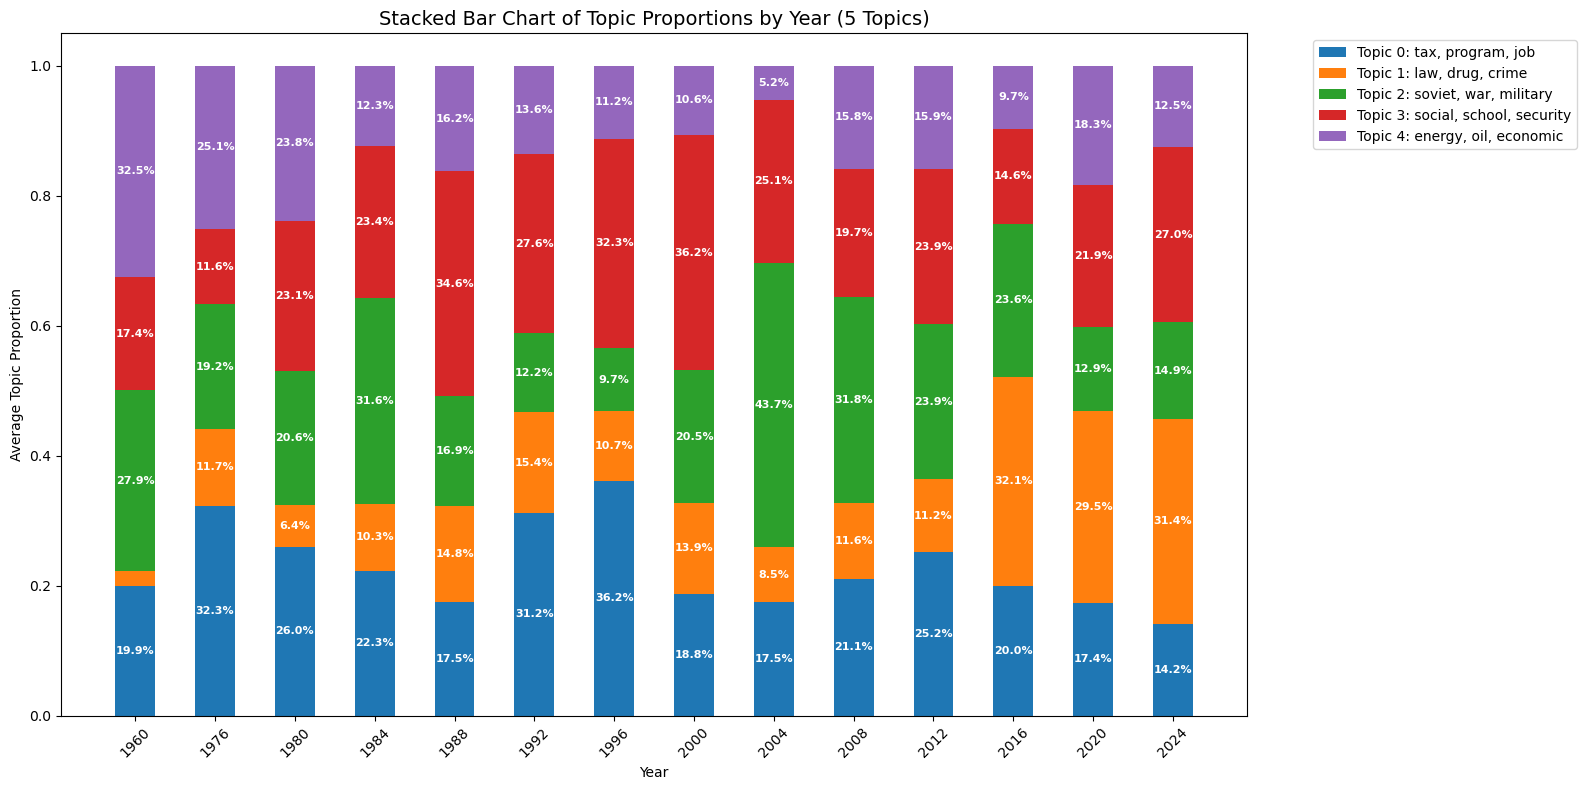

In [26]:
import matplotlib.pyplot as plt

# Prepare labels for 5 topics
legend_labels_5 = []
for topic_id in range(ldaseq_5_topics.num_topics):
    top_terms = ldaseq_5_topics.print_topic(topic=topic_id, time=0, top_terms=3)
    short_label = f"Topic {topic_id}: " + ", ".join([term for term, _ in top_terms])
    legend_labels_5.append(short_label)

# Plot setup
fig, ax = plt.subplots(figsize=(16, 8))
bar_width = 1.5

years_5 = topic_trends_5.index.tolist()
spacing = 3  # controls how far apart the bars are
x_positions_5 = [i * spacing for i in range(len(years_5))]  # spread out positions
bottoms_5 = [0] * len(years_5)

# Draw stacked bars for 5 topics
for i in range(ldaseq_5_topics.num_topics):
    values = topic_trends_5[f"Topic {i}"].values
    bars = ax.bar(x_positions_5, values, width=bar_width, bottom=bottoms_5, label=legend_labels_5[i])
    
    # Add percentage labels
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0.03:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottoms_5[j] + height / 2,
                f"{height*100:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='white',
                fontweight='bold'
            )
    bottoms_5 = [sum(x) for x in zip(bottoms_5, values)]

# Customize axes
ax.set_title("Stacked Bar Chart of Topic Proportions by Year (5 Topics)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Average Topic Proportion")
ax.set_ylim(0, 1.05)

# Set x-axis labels to actual years, spaced accordingly
ax.set_xticks(x_positions_5)
ax.set_xticklabels(years_5, rotation=45)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### num_topics = 4

In [ ]:
# Tokenize cleaned text into words
df_transcripts["tokens"] = df_transcripts["cleaned_text"].apply(lambda x: x.split())

# Group tokenized speeches by year and sort chronologically
grouped = df_transcripts.groupby("year")["tokens"].apply(list).sort_index()

# Flatten speeches into one document per speech; count speeches per year
all_docs_4_topics = [doc for year_docs in grouped for doc in year_docs]
timeslices_4_topics = [len(year_docs) for year_docs in grouped]

# Create a dictionary of words and a bag-of-words corpus
dictionary_4_topics = corpora.Dictionary(all_docs_4_topics)
corpus_4_topics = [dictionary_4_topics.doc2bow(text) for text in all_docs_4_topics]

# Train the Dynamic Topic Model with 7 topics
ldaseq_4_topics = LdaSeqModel(
    corpus=corpus_4_topics,
    time_slice=timeslices_4_topics,
    id2word=dictionary_4_topics,
    num_topics=4,
    initialize='gensim',
    random_state=42
)

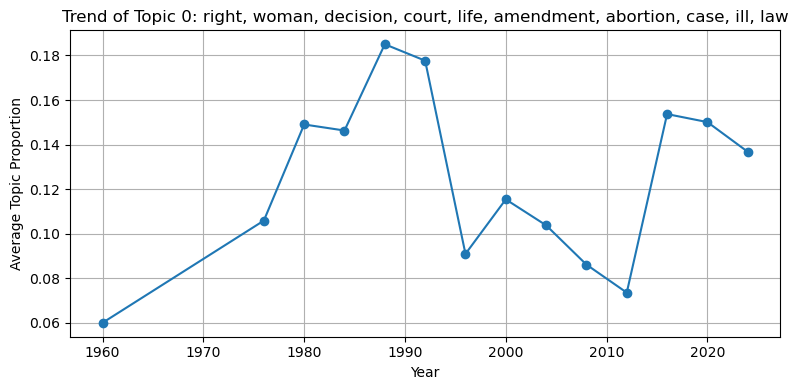

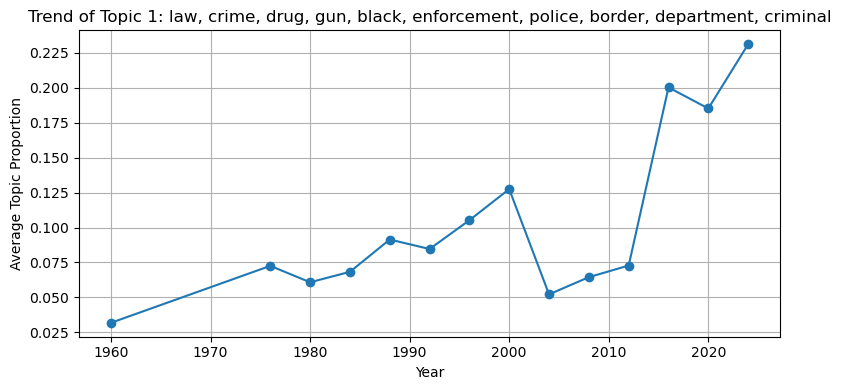

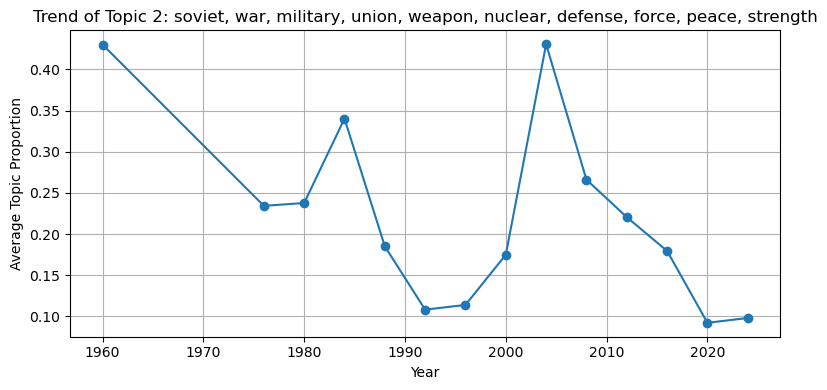

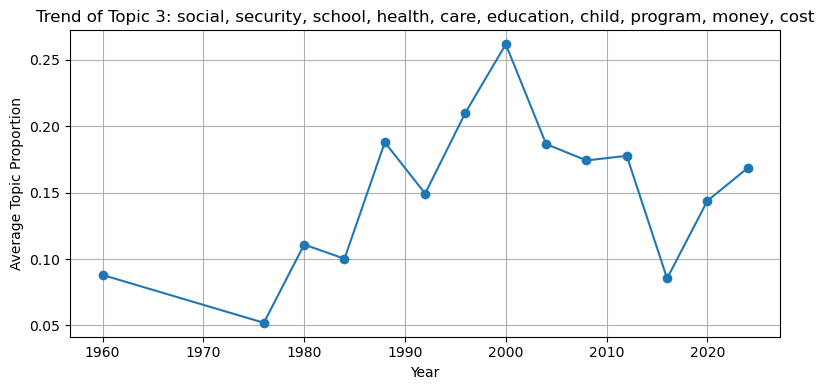

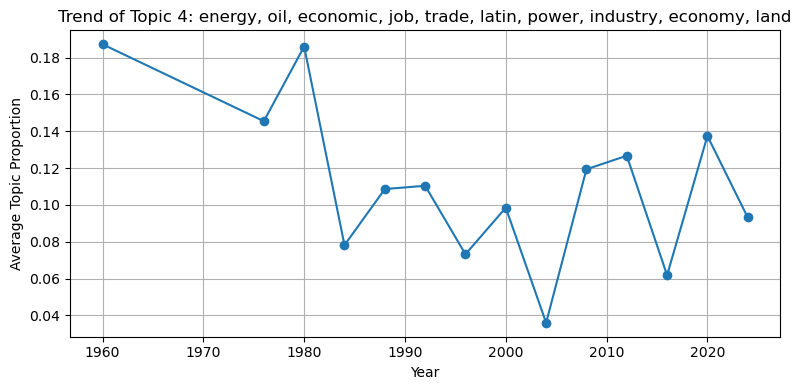

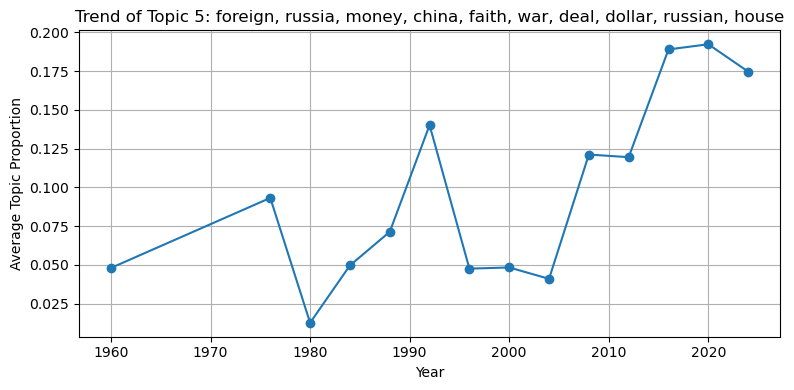

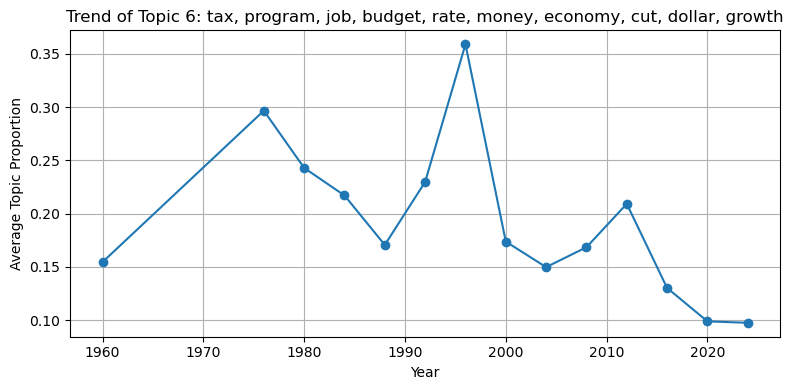

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get topic proportions per document
doc_topic_dists_7 = [ldaseq_7_topics.doc_topics(i) for i in range(len(all_docs_7_topics))]
topic_df_7 = pd.DataFrame(doc_topic_dists_7, columns=[f"Topic {i}" for i in range(ldaseq_7_topics.num_topics)])

# Step 2: Match each document to its corresponding year
years_per_doc_7 = []
for year, docs in grouped.items():
    years_per_doc_7.extend([year] * len(docs))
topic_df_7["year"] = years_per_doc_7

# Step 3: Average topic proportions per year
topic_trends_7 = topic_df_7.groupby("year").mean()

# Step 4: Get top 10 terms per topic (from the first time slice)
topic_labels_7 = []
for topic_id in range(ldaseq_7_topics.num_topics):
    top_terms = ldaseq_7_topics.print_topic(topic=topic_id, time=0, top_terms=10)
    label = f"Topic {topic_id}: " + ", ".join([term for term, _ in top_terms])
    topic_labels_7.append(label)

# Step 5: Plot each topic's trend over time
for i, col in enumerate(topic_trends_7.columns):
    plt.figure(figsize=(8, 4))
    plt.plot(topic_trends_7.index, topic_trends_7[col], marker='o')
    plt.title(f"Trend of {topic_labels_7[i]}")
    plt.xlabel("Year")
    plt.ylabel("Average Topic Proportion")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

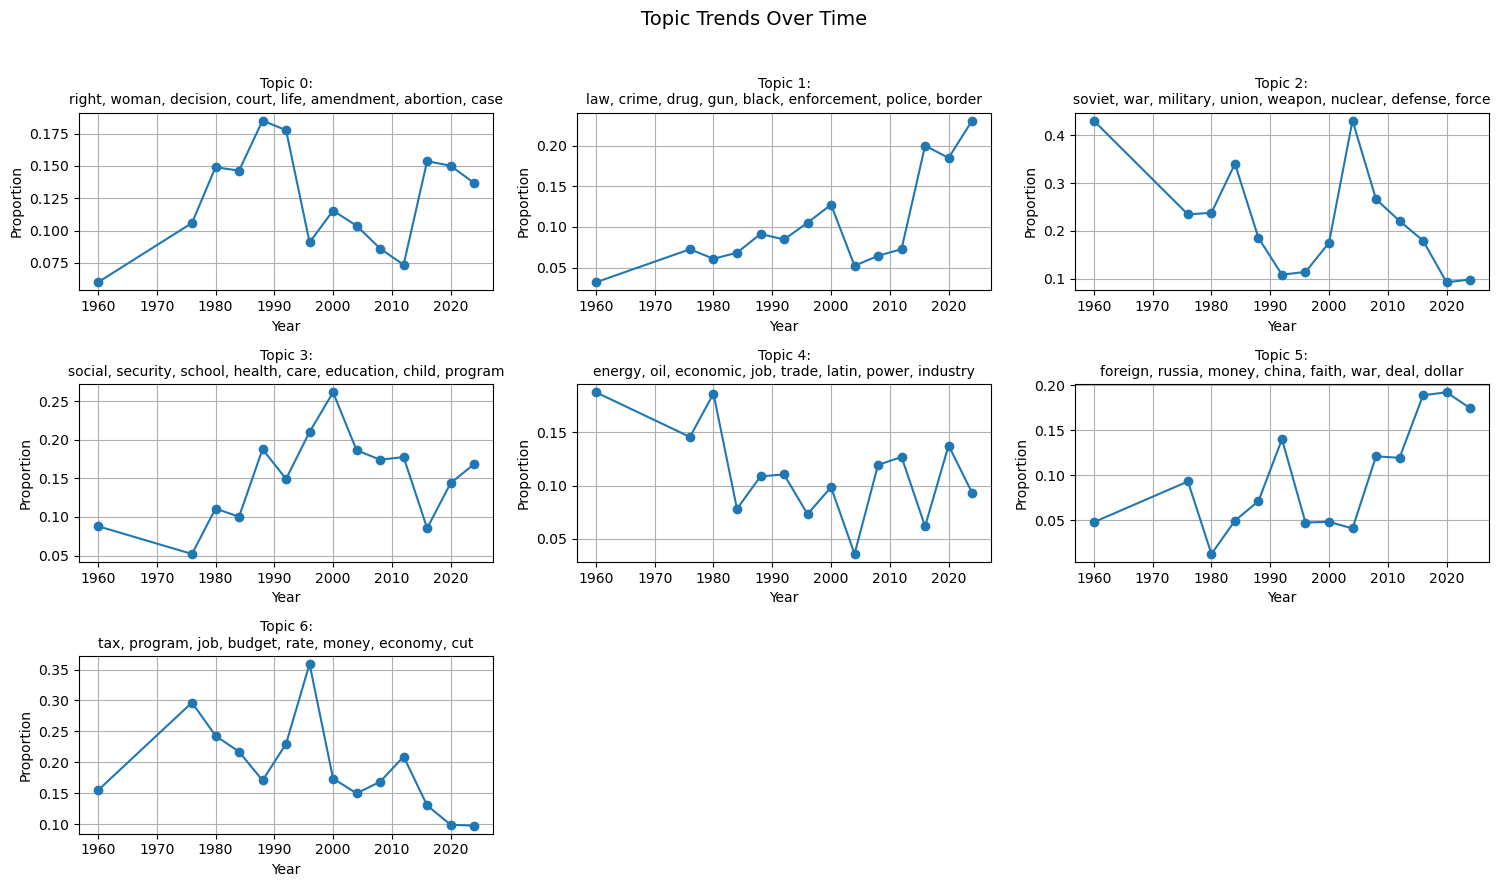

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Get topic proportions per document
doc_topic_dists_7 = [ldaseq_7_topics.doc_topics(i) for i in range(len(all_docs_7_topics))]
topic_df_7 = pd.DataFrame(doc_topic_dists_7, columns=[f"Topic {i}" for i in range(ldaseq_7_topics.num_topics)])

# Match each document to its year
years_per_doc_7 = []
for year, docs in grouped.items():
    years_per_doc_7.extend([year] * len(docs))
topic_df_7["year"] = years_per_doc_7

# Average topic proportions per year
topic_trends_7 = topic_df_7.groupby("year").mean()

# Get top 8 terms per topic (from the first time slice)
topic_labels_7 = []
for topic_id in range(ldaseq_7_topics.num_topics):
    top_terms = ldaseq_7_topics.print_topic(topic=topic_id, time=0, top_terms=8)
    label = f"Topic {topic_id}:\n" + ", ".join([term for term, _ in top_terms])
    topic_labels_7.append(label)

# Plot in a grid (adjust layout based on number of topics)
n_topics = ldaseq_7_topics.num_topics
n_rows = (n_topics + 2) // 3  # 3 columns per row
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i in range(n_topics):
    ax = axes[i]
    ax.plot(topic_trends_7.index, topic_trends_7[f"Topic {i}"], marker='o')
    ax.set_title(topic_labels_7[i], fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion")
    ax.grid(True)

# Hide any unused subplots
for j in range(n_topics, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Topic Trends Over Time", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [33]:
from gensim.models.ldaseqmodel import LdaSeqModel
from gensim import corpora

# Tokenize cleaned text into words
df_transcripts["tokens"] = df_transcripts["cleaned_text"].apply(lambda x: x.split())

# Group tokenized speeches by year and sort chronologically
grouped = df_transcripts.groupby("year")["tokens"].apply(list).sort_index()

# Flatten speeches into one document per speech; count speeches per year
all_docs_10_topics = [doc for year_docs in grouped for doc in year_docs]
timeslices_10_topics = [len(year_docs) for year_docs in grouped]

# Create a dictionary of words and a bag-of-words corpus
dictionary_10_topics = corpora.Dictionary(all_docs_10_topics)
corpus_10_topics = [dictionary_10_topics.doc2bow(text) for text in all_docs_10_topics]

# Train the Dynamic Topic Model with 10 topics
ldaseq_10_topics = LdaSeqModel(
    corpus=corpus_10_topics,
    time_slice=timeslices_10_topics,
    id2word=dictionary_10_topics,
    num_topics=10,
    initialize='gensim',
    random_state=42
)

# Print the top 10 terms per topic per year
for topic_id in range(10):
    print(f"\n=== Topic {topic_id} ===")
    for t, year in enumerate(grouped.index):
        terms = ldaseq_10_topics.print_topic(topic=topic_id, time=t, top_terms=10)
        print(f"Year {year}: {terms}")

/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:298: RuntimeWarning: divide by zero encountered in scalar divide
  convergence = np.fabs((bound - old_bound) / old_bound)



=== Topic 0 ===
Year 1960: [('tax', 0.0945140683399238), ('budget', 0.02847074771503844), ('rate', 0.02733613590395075), ('cut', 0.022912847117901994), ('money', 0.021276792851735317), ('program', 0.019548803778127868), ('dollar', 0.018788913821497923), ('increase', 0.01821942503736896), ('economy', 0.017712591246548188), ('deficit', 0.016525453163226542)]
Year 1976: [('tax', 0.09744689912227236), ('budget', 0.028141300368025264), ('rate', 0.027602850674294233), ('cut', 0.02369537921995035), ('money', 0.02079224586946036), ('program', 0.0187510241304112), ('increase', 0.018686582302202253), ('dollar', 0.017822613224760527), ('economy', 0.017439617898628013), ('deficit', 0.01691883718326139)]
Year 1980: [('tax', 0.1030711194150183), ('budget', 0.02763879859432603), ('rate', 0.026746934052618306), ('cut', 0.025803480497954688), ('money', 0.02030590291971321), ('increase', 0.018987009464751084), ('deficit', 0.017712171142273195), ('economy', 0.01698886965219563), ('program', 0.0167293735

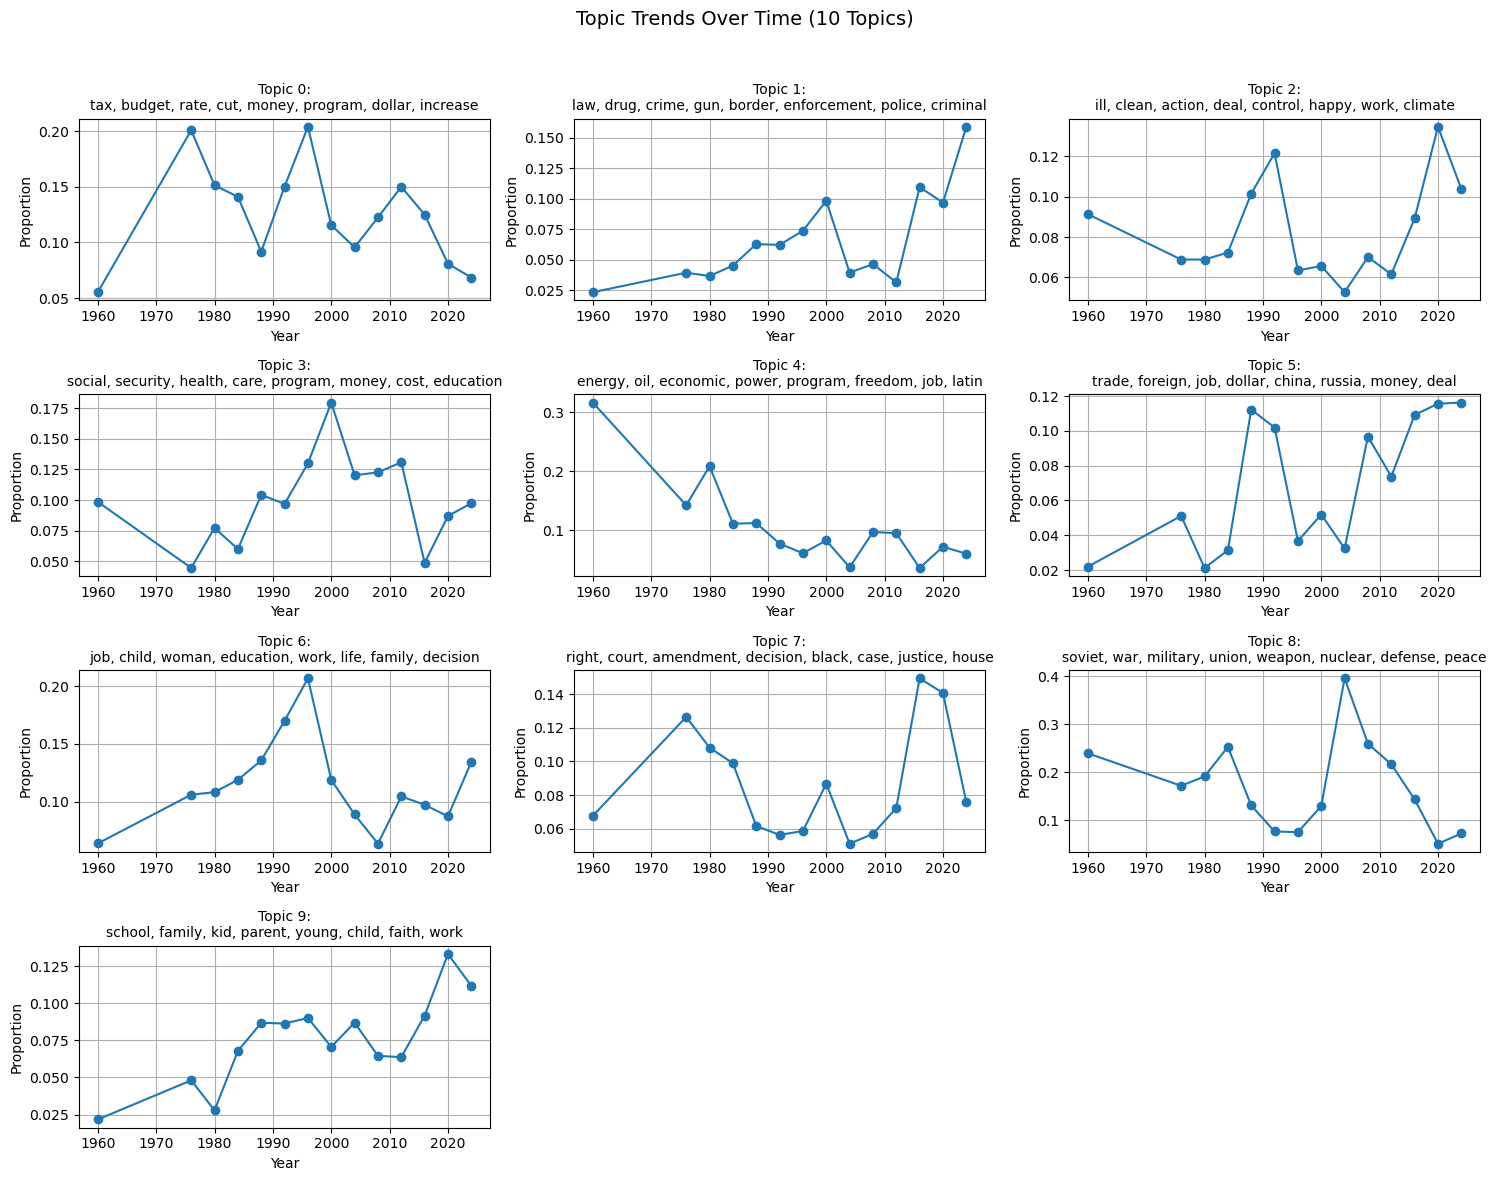

In [34]:
# Get topic proportions per document
doc_topic_dists_10 = [ldaseq_10_topics.doc_topics(i) for i in range(len(all_docs_10_topics))]
topic_df_10 = pd.DataFrame(doc_topic_dists_10, columns=[f"Topic {i}" for i in range(ldaseq_10_topics.num_topics)])

# Match each document to its year
years_per_doc_10 = []
for year, docs in grouped.items():
    years_per_doc_10.extend([year] * len(docs))
topic_df_10["year"] = years_per_doc_10

# Average topic proportions per year
topic_trends_10 = topic_df_10.groupby("year").mean()

# Get top 8 terms per topic (from the first time slice)
topic_labels_10 = []
for topic_id in range(ldaseq_10_topics.num_topics):
    top_terms = ldaseq_10_topics.print_topic(topic=topic_id, time=0, top_terms=8)
    label = f"Topic {topic_id}:\n" + ", ".join([term for term, _ in top_terms])
    topic_labels_10.append(label)

# Plot in a grid (adjust layout based on number of topics)
n_topics = ldaseq_10_topics.num_topics
n_rows = (n_topics + 2) // 3  # 3 columns per row
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i in range(n_topics):
    ax = axes[i]
    ax.plot(topic_trends_10.index, topic_trends_10[f"Topic {i}"], marker='o')
    ax.set_title(topic_labels_10[i], fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion")
    ax.grid(True)

# Hide any unused subplots
for j in range(n_topics, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Topic Trends Over Time (10 Topics)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()